# ④ 심화 분석 — 인구 Join & 혼잡 패턴
**11team · 서울 지하철 혼잡도 분석**

1. **방향성**(역 성격: 주거 vs 업무)을 외부 인구데이터로 실증
2. **혼잡 = 승차 + 하차** 기준으로 역×시간 패턴 도출 (출근·퇴근 둘 다)
> ⚠️ 혼잡 '규모'(승하차 합)와 '방향성'(아침 승/하차 비율)은 다른 축 — 구분해서 본다.

In [1]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt, seaborn as sns, matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
NAVY, RED, BLUE, PUR = '#1D3557', '#E63946', '#457B9D', '#7B2CBF'

SUBWAY_DIR = r"C:/Users/최용우/Downloads/drive-download-20260625T013956Z-3-001/dataset"
EXT_DIR    = r"C:/Users/최용우/claude/yearsubway_11team/external_data"
def read_csv_auto(p, **k):
    for e in ['utf-8-sig','cp949','euc-kr','utf-8']:
        try: return pd.read_csv(p, encoding=e, **k)
        except UnicodeDecodeError: continue

metro = read_csv_auto(f"{SUBWAY_DIR}/Seoul_subway_data_20210705.csv")
loc   = read_csv_auto(f"{SUBWAY_DIR}/subway_location_data.csv")
on_cols  = [c for c in metro.columns if '승차인원' in c]
off_cols = [c for c in metro.columns if '하차인원' in c]
slots    = [c.replace(' 승차인원','') for c in on_cols]
jun = metro[metro['사용월']==202106].copy()

## 1. 역 → 자치구 매핑 (서울 외 제외, 서울역 보정)

In [2]:
def keyf(x): return re.sub(r'역$','', re.sub(r'\(.*?\)','', str(x))).strip()
def get_gu(a):
    p=str(a).split(); return p[1] if p and p[0].startswith('서울') else None
loc['key']=loc['지하철역'].apply(keyf); loc['자치구']=loc['주소'].apply(get_gu)
lk = loc.dropna(subset=['자치구']).drop_duplicates('key').set_index('key')['자치구']
st = jun.groupby('지하철역')[on_cols+off_cols].sum().reset_index()
st['key']=st['지하철역'].apply(keyf); st['자치구']=st['key'].map(lk)
st.loc[st['지하철역']=='서울역','자치구']='중구'
seoul = st[st['자치구'].notna()].copy()
print("서울 분석역:", len(seoul))

서울 분석역: 296


## 2. 주간인구지수 Join — 방향성(역 성격) 실증
아침(07–09시) **승차비율** = 아침승차/(아침승차+아침하차)로 역 성격을 본다.
- 낮음 → 아침에 **내리는** 업무지구 / 높음 → 아침에 **타는** 주거지(베드타운)

In [3]:
ju = pd.read_excel(f"{EXT_DIR}/서울특별시_자치구별 연령별 주간 야간 인구_20201231.xlsx", header=1)
ju['행정구역별']=ju['행정구역별'].ffill()
gu = ju[(ju['성별']=='계')&(ju['연령별']=='합계')&(ju['행정구역별']!='서울특별시')].copy()
gu['자치구']=gu['행정구역별'].str.replace('　','',regex=False).str.strip()
gu_idx = gu.set_index('자치구')['주간 인구 지수']
am_on  = [c for c in on_cols  if c.startswith(('07시','08시'))]
am_off = [c for c in off_cols if c.startswith(('07시','08시'))]
seoul['아침승차비율'] = seoul[am_on].sum(axis=1)/(seoul[am_on].sum(axis=1)+seoul[am_off].sum(axis=1))
seoul['주간인구지수'] = seoul['자치구'].map(gu_idx)
seoul['유형'] = np.where(seoul['아침승차비율']<0.4,'업무지구',np.where(seoul['아침승차비율']>0.6,'베드타운','혼합'))
v = seoul[(seoul[am_on].sum(axis=1)+seoul[am_off].sum(axis=1))>10000].dropna(subset=['주간인구지수'])
print(f"분석역 {len(v)} | 주간인구지수 ↔ 아침승차비율 상관 = {v['주간인구지수'].corr(v['아침승차비율']):.3f}")

분석역 296 | 주간인구지수 ↔ 아침승차비율 상관 = -0.672


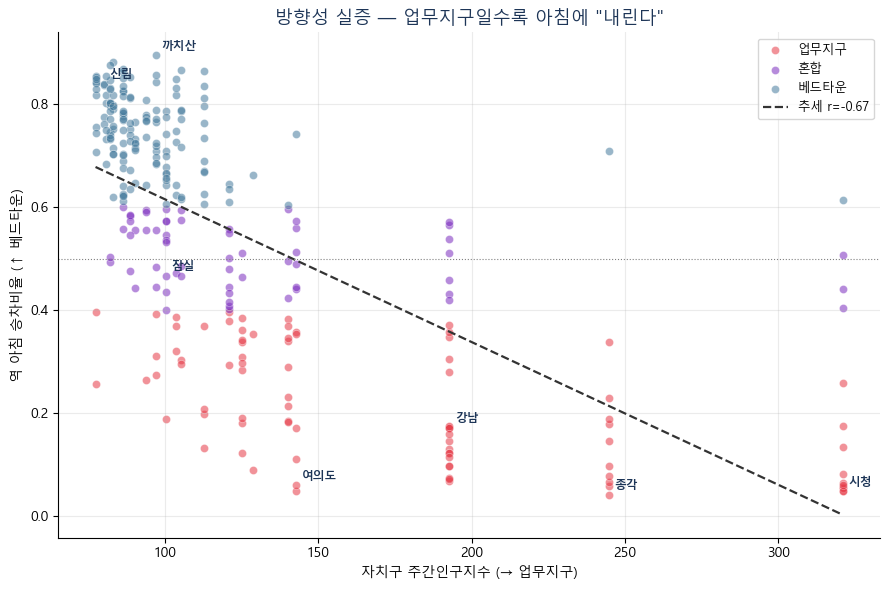

In [4]:
cm={'업무지구':RED,'베드타운':BLUE,'혼합':PUR}
fig, ax = plt.subplots(figsize=(9,6))
for t in ['업무지구','혼합','베드타운']:
    sub=v[v['유형']==t]; ax.scatter(sub['주간인구지수'],sub['아침승차비율'],c=cm[t],s=34,alpha=.55,edgecolors='white',lw=.4,label=t)
mq,bq=np.polyfit(v['주간인구지수'],v['아침승차비율'],1); xs=np.array([v['주간인구지수'].min(),v['주간인구지수'].max()])
ax.plot(xs,mq*xs+bq,color='#333',lw=1.6,ls='--',label=f"추세 r={v['주간인구지수'].corr(v['아침승차비율']):.2f}")
ax.axhline(0.5,color='gray',ls=':',lw=.8)
for r in ['시청','종각','강남','여의도','신림','까치산','잠실(송파구청)']:
    row=v[v['지하철역']==r]
    if len(row): ax.annotate(r.split('(')[0],(row['주간인구지수'].iloc[0],row['아침승차비율'].iloc[0]),fontsize=8.5,fontweight='bold',color=NAVY,xytext=(4,4),textcoords='offset points')
ax.set_xlabel('자치구 주간인구지수 (→ 업무지구)'); ax.set_ylabel('역 아침 승차비율 (↑ 베드타운)')
ax.set_title('방향성 실증 — 업무지구일수록 아침에 "내린다"',color=NAVY,fontsize=13)
ax.legend(fontsize=9,loc='upper right'); ax.spines[['top','right']].set_visible(False); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 3. 혼잡 패턴 — **승차 + 하차** 둘 다
혼잡 = 승차 + 하차 인원. 역×시간 단위로 집계해 출근·퇴근 혼잡을 모두 본다.

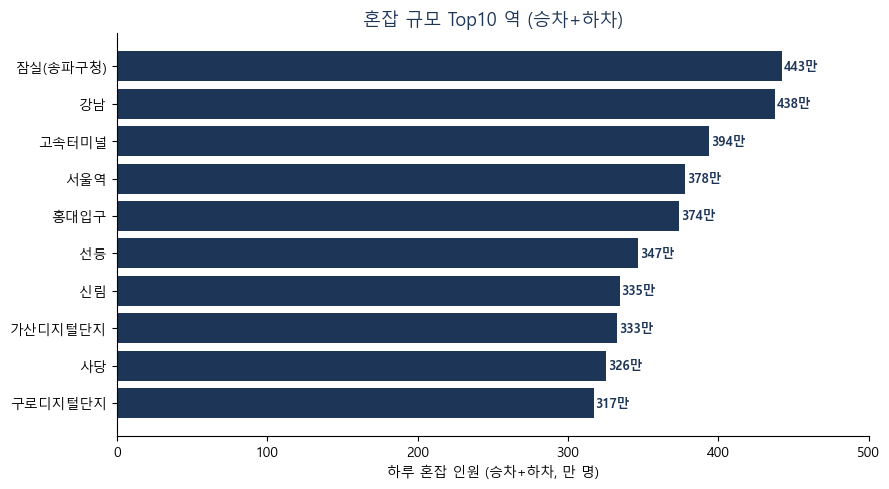

In [5]:
slot_sum = pd.DataFrame({slots[i]: seoul[on_cols[i]].values + seoul[off_cols[i]].values
                         for i in range(len(slots))}, index=seoul['지하철역'].values)
seoul['총혼잡'] = slot_sum.sum(axis=1).values
# 혼잡 규모 Top10 (승하차 합)
top10 = seoul.nlargest(10,'총혼잡')[['지하철역','자치구','유형','총혼잡']].iloc[::-1]
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(top10['지하철역'], top10['총혼잡']/1e4, color=NAVY)
for i,vv in enumerate(top10['총혼잡']): ax.text(vv/1e4+1,i,f'{vv/1e4:.0f}만',va='center',fontsize=9,color=NAVY,fontweight='bold')
ax.set_xlabel('하루 혼잡 인원 (승차+하차, 만 명)'); ax.set_title('혼잡 규모 Top10 역 (승차+하차)',color=NAVY,fontsize=13)
ax.spines[['top','right']].set_visible(False); ax.margins(x=0.13); plt.tight_layout(); plt.show()

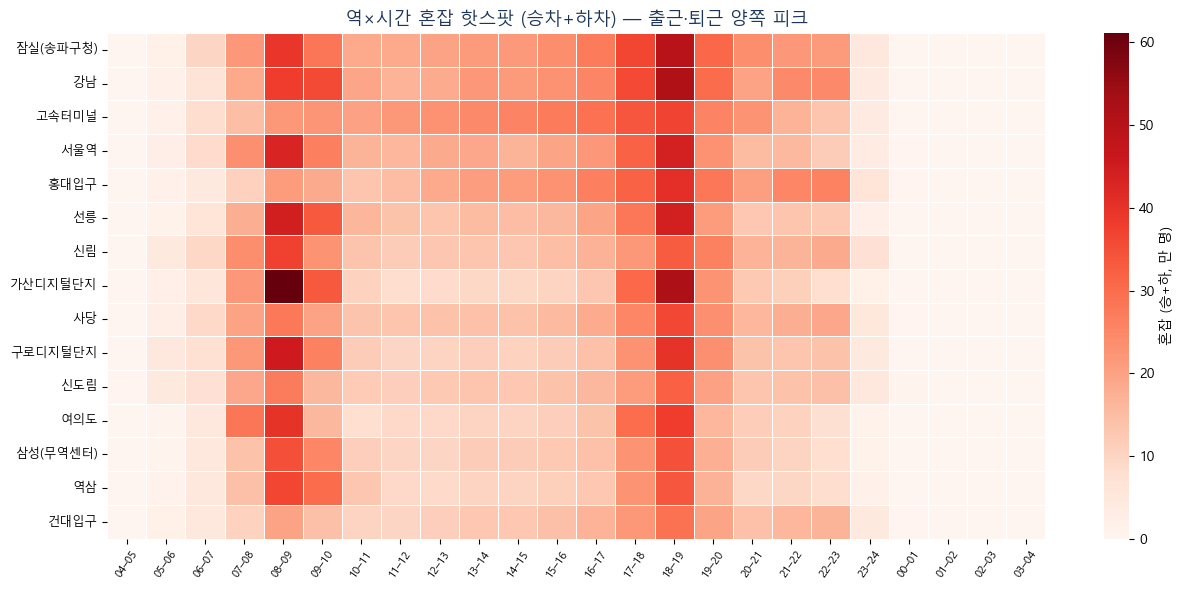

In [6]:
# 역×시간 히트맵 (승차+하차)
top15 = seoul.nlargest(15,'총혼잡')['지하철역']
mat = slot_sum.loc[top15]; mat.columns=[s.replace('시-','–').replace('시','') for s in slots]
fig, ax = plt.subplots(figsize=(13,6))
sns.heatmap(mat/1e4, cmap='Reds', linewidths=.4, linecolor='white', cbar_kws={'label':'혼잡 (승+하, 만 명)'}, ax=ax)
ax.set_title('역×시간 혼잡 핫스팟 (승차+하차) — 출근·퇴근 양쪽 피크',color=NAVY,fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=55,fontsize=8); plt.yticks(rotation=0,fontsize=9); plt.tight_layout(); plt.show()

## 5. 기상 Join — 월별 이용량과 날씨 *(시계열 보너스)*
2015–2021 **월별** 지하철 총이용 ↔ 월 평균기온·강수량. (분석 단위가 역→월로 바뀌는 시계열)

월 78개 | 이용↔기온 r=0.089 | 이용↔강수 r=-0.103


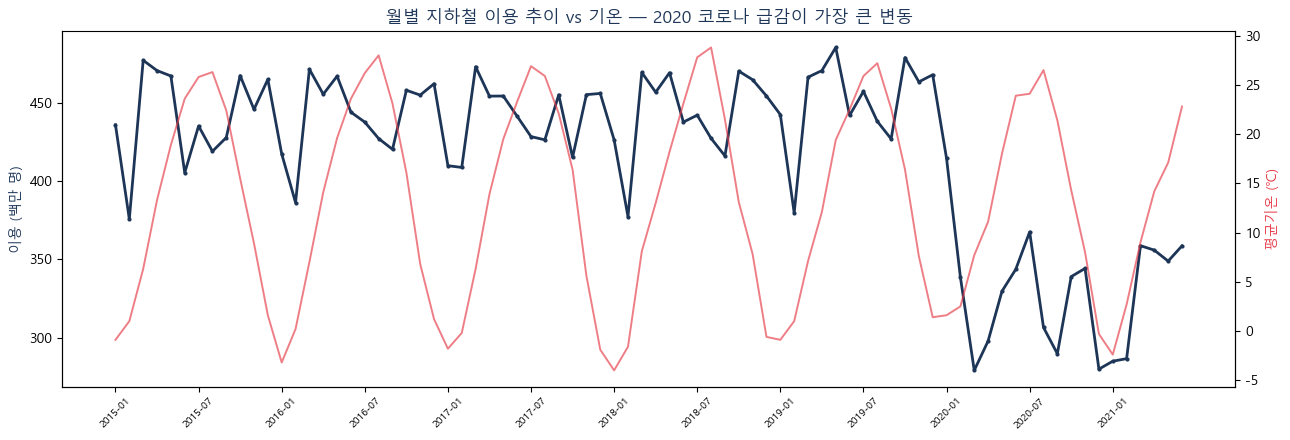

In [7]:
import os
mall = metro.groupby('사용월')[on_cols+off_cols].sum().sum(axis=1).reset_index()
mall.columns = ['사용월','총이용']
mall['년월'] = pd.to_datetime(mall['사용월'].astype(str), format='%Y%m').dt.strftime('%Y-%m')
def load_w(prefix, col):
    fn = [f for f in os.listdir(EXT_DIR) if f.startswith(prefix)][0]
    w = read_csv_auto(f"{EXT_DIR}/{fn}", skiprows=7, skipinitialspace=True)
    w.columns = [c.strip() for c in w.columns]
    w['년월'] = w.iloc[:,0].astype(str).str.strip()
    w[col] = pd.to_numeric(w.iloc[:,2], errors='coerce')
    return w[['년월', col]]
m = mall.merge(load_w('기온','기온'), on='년월', how='left').merge(load_w('강수','강수'), on='년월', how='left')
m = m[(m['사용월']>=201501) & (m['사용월']<=202106)].reset_index(drop=True)
print(f"월 {len(m)}개 | 이용↔기온 r={m['총이용'].corr(m['기온']):.3f} | 이용↔강수 r={m['총이용'].corr(m['강수']):.3f}")

fig, ax = plt.subplots(figsize=(13,4.5)); x = range(len(m))
ax.plot(x, m['총이용']/1e6, color=NAVY, lw=2, marker='.', ms=4, label='월 지하철 이용')
ax.set_ylabel('이용 (백만 명)', color=NAVY)
ax2 = ax.twinx(); ax2.plot(x, m['기온'], color=RED, lw=1.4, alpha=.65, label='평균기온')
ax2.set_ylabel('평균기온 (℃)', color=RED)
step = max(1, len(m)//13); ax.set_xticks(list(x)[::step]); ax.set_xticklabels(m['년월'][::step], rotation=45, fontsize=7.5)
ax.set_title('월별 지하철 이용 추이 vs 기온 — 2020 코로나 급감이 가장 큰 변동',color=NAVY,fontsize=12.5)
ax.spines[['top']].set_visible(False); plt.tight_layout(); plt.show()

**해석** — 시계열 변동의 가장 큰 요인은 **2020년 코로나19**(급감)다. 기온·강수와의 단순 상관은 코로나 효과에 가려 약하게 나오므로, *상관≠인과* 원칙에 따라 신중히 해석한다. (계절성: 혹서·혹한기 소폭 감소 경향)

---
## ✅ 심화 요약
- **방향성**(역 성격): 주간인구지수 ↔ 아침승차비율 상관 −0.67 → 업무지구/베드타운 실증
- **혼잡 규모**(승차+하차): 강남·잠실·가산디지털단지 등이 최대, 히트맵에 **출근·퇴근 양쪽 피크** 모두 표시
- **기상**(시계열): 월별 이용은 2020 코로나로 급감, 날씨는 부차적 요인
### ▶ 다음 (⑤ 솔루션)
출근/퇴근 분리 권고 + folium 지도